# Daymet Daily V4 R1 from NASA Earthdata Cloud via OPeNDAP (Hyrax)
### Regional and temporal subsetting for the Tennessee Valley Authority (TVA) power service area

*ORNL DAAC Tutorial by Bharat Sharma — built on earlier works by Michele Thornton and Rupesh Shrestha (ORNL DAAC)*

## 1. Overview

Daymet daily data now live in the **NASA Earthdata Cloud** (NASA AWS), and the legacy ORNL DAAC THREDDS
endpoint is retired. This notebook shows the current, supported way to pull a **space + time subset**
of Daymet Daily V4 R1 out of the cloud archive **without downloading whole continental files** — using the
NASA Earthdata **OPeNDAP Hyrax** server and the **DAP4** protocol.

A single Daymet daily North American granule is one variable, one year, on a 1 km grid
(8075 x 7814 x 365) — roughly 90 GB uncompressed. The TVA power service area covers
less 1% of that grid (437k Grid Cells covered by TVA vs total 63M gridcells in NA).

### What this notebook does

| Step | Action | Tool |
|:--|:--|:--|
| 2 | Authenticate with Earthdata Login (EDL) | `earthaccess` |
| 3 | Build the region of interest from a TVA polygon, reproject to Daymet's Lambert Conformal Conic grid | `geopandas` |
| 4 | Set the time range and variables of interest | `datetime` |
| 5 | Discover OPeNDAP granule URLs from NASA's CMR | `pydap.client.get_cmr_urls` |
| 6 | Open a remote granule lazily over DAP4 and inspect it | `xarray` + `pydap` |
| 7 | Subset in space and time, concatenate years, write netCDF | `xarray` |
| 8 | Clip to the TVA polygon, map it, export GeoTIFF | `rioxarray` |
| 9 | Regional analyses: area-mean time series, hot-day counts, single-pixel extraction | `xarray` / `matplotlib` |
| 10 | Optional: bulk parallel streaming of many granules | `pydap.client.to_netcdf` |

### Prerequisites

1. A free **[NASA Earthdata Login](https://urs.earthdata.nasa.gov/)** account.
2. Your EDL profile must have OPeNDAP-related **applications authorized**
   (EDL profile -> *Applications* -> *Authorized Apps*). 
3. Python 3.11+ and the packages in the next cell. Suggested environment:

```bash
conda create -n daymet_opendap -c conda-forge python=3.12 earthaccess "pydap>=3.5.5" \
    "xarray>=2025.1" netcdf4 geopandas rioxarray matplotlib requests jupyterlab
conda activate daymet_opendap
```

### Data citation

> Thornton, M. M., Shrestha, R., Wei, Y., Thornton, P. E., &amp; Kao, S.-C. (2022).
> *Daymet: Daily Surface Weather Data on a 1-km Grid for North America, Version 4 R1 (Version 4.1)*.
> ORNL Distributed Active Archive Center. https://doi.org/10.3334/ORNLDAAC/2129 Date Accessed: 2026-09-23

Collection landing page:
[Daymet Daily V4 R1 in the Earthdata catalog](https://www.earthdata.nasa.gov/data/catalog/ornl-cloud-daymet-daily-v4r1-2129-4.1) |
OPeNDAP entry point: [opendap.earthdata.nasa.gov](https://opendap.earthdata.nasa.gov/)

### Daymet at a glance

| Variable | Description (units) |
|:--|:--|
| `tmax` | Daily maximum 2 m air temperature (deg C) |
| `tmin` | Daily minimum 2 m air temperature (deg C) |
| `prcp` | Daily total precipitation (mm/day) |
| `srad` | Incident shortwave radiation flux density (W/m2) |
| `vp` | Water vapor pressure (Pa) |
| `swe` | Snow water equivalent (kg/m2) |
| `dayl` | Duration of the daylight period (s/day) |

| Region code | Domain | Years |
|:--|:--|:--|
| `na` | Continental North America | 1980 - present |
| `hi` | Hawaii | 1980 - present |
| `pr` | Puerto Rico | 1950 - present |

Granule naming in the cloud archive:
`Daymet_Daily_V4R1.daymet_v4_daily_<region>_<variable>_<year>.nc`

Daymet uses a **365-day year**: December 31 is dropped in leap years. The grid is
**Lambert Conformal Conic**, so spatial subsetting happens in projected metres (`x`, `y`),
not in degrees.

In [1]:
import datetime as dt
import json
import os
import time
from pathlib import Path

import earthaccess
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
import pydap
import requests
import rioxarray  # noqa: F401  (registers the .rio accessor)
import xarray as xr
from pydap.client import get_cmr_urls, open_url
from pydap.client import to_netcdf as dap_to_netcdf
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore")

print("This notebook was produced with:")
for m in (earthaccess, pydap, xr, gpd, np):
    print(f"  {m.__name__:14s} {m.__version__}")

WORKDIR = Path("./daymet_tva")
(WORKDIR / "data").mkdir(parents=True, exist_ok=True)
print("\nOutputs ->", WORKDIR.resolve())

This notebook was produced with:
  earthaccess    0.19.0
  pydap          3.5.11
  xarray         2026.7.0
  geopandas      1.1.1
  numpy          2.3.2

Outputs -> /Users/ud4/repos/GitHub/sharma-bharat/DAAC/Task1/daymet_tva


## 2. Authenticate with Earthdata Login

Everything behind `opendap.earthdata.nasa.gov` is authenticated. `earthaccess` handles the EDL
handshake and hands us a `requests.Session` carrying the right credentials/token, which we then
pass to `pydap`/`xarray`.

* `strategy="netrc"` reuses credentials already stored in `~/.netrc`.
* `strategy="interactive"` prompts for username/password; `persist=True` writes them to `~/.netrc`
  so you only do this once.

In [2]:
from earthaccess.exceptions import LoginStrategyUnavailable

try:
    auth = earthaccess.login(strategy="netrc", persist=True)
except LoginStrategyUnavailable:
    auth = earthaccess.login(strategy="interactive", persist=True)

# A requests.Session carrying EDL authorization; pass this to pydap / xarray.
my_session = auth.get_session()
print("Authenticated:", auth.authenticated)
print("Session:", type(my_session).__name__)

Authenticated: True
Session: SessionWithHeaderRedirection


## 3. Region of interest: the TVA power service area

Any polygon works — a watershed, a county, a park, a utility footprint. Here we use the
**TVA Power Service Area** polygon published as a public ArcGIS feature service
([item page](https://www.arcgis.com/home/item.html?id=ae42436a90054278abc13f10017f0fd6)).
The polygon is cached locally on first download, so the notebook is reproducible offline afterward.

Swap in your own polygon by pointing `LOCAL_POLYGON` at a shapefile/GeoJSON, e.g. the Great Smoky
Mountains boundary in the older ORNL DAAC tutorials.

In [3]:
LOCAL_POLYGON = None   # e.g. "bnds/GRSM_BOUNDARY_POLYGON_fid17.shp" to use your own polygon
CACHE = WORKDIR / "tva_power_service_area.geojson"

TVA_SERVICE = (
    "https://services5.arcgis.com/bPacKTm9cauMXVfn/arcgis/rest/services/"
    "TVA_Power_Service_Area/FeatureServer/0/query"
)

if LOCAL_POLYGON:
    roi = gpd.read_file(LOCAL_POLYGON)
elif CACHE.exists():
    roi = gpd.read_file(CACHE)
else:
    params = {"where": "1=1", "outFields": "OID,Name", "returnGeometry": "true",
              "outSR": 4326, "f": "geojson"}
    r = requests.get(TVA_SERVICE, params=params, timeout=120)
    r.raise_for_status()
    roi = gpd.GeoDataFrame.from_features(r.json()["features"], crs="EPSG:4326")
    roi.to_file(CACHE, driver="GeoJSON")
    print("Cached ->", CACHE)

# dissolve multiple parts into a single region of interest
roi = roi.dissolve().reset_index(drop=True)[["geometry"]]

print("CRS              :", roi.crs)
print("Geographic bounds:", np.round(roi.total_bounds, 3))

CRS              : EPSG:4326
Geographic bounds: [-90.347  32.323 -81.647  37.596]


### Reproject the polygon to Daymet's Lambert Conformal Conic grid

Two equivalent ways to get Daymet's CRS:

1. Read it off any Daymet granule with `rioxarray` (`ds.rio.crs`) — done later in Step 6.
2. Use the PROJ string from the
   [Daymet Daily V4 R1 User Guide](https://daac.ornl.gov/DAYMET/guides/Daymet_Daily_V4R1.html):

```
+proj=lcc +ellps=WGS84 +a=6378137 +b=6356752.314245 +lat_1=25 +lat_2=60
+lon_0=-100 +lat_0=42.5 +x_0=0 +y_0=0 +units=m +no_defs
```

We keep **two** bounding boxes: geographic (WGS84) for CMR metadata searches, and LCC (metres)
for the actual OPeNDAP subsetting.

In [4]:
DAYMET_PROJ = ("+proj=lcc +ellps=WGS84 +a=6378137 +b=6356752.314245 "
               "+lat_1=25 +lat_2=60 +lon_0=-100 +lat_0=42.5 +x_0=0 +y_0=0 "
               "+units=m +no_defs")

roi_wgs84 = roi.to_crs(epsg=4326)
roi_lcc = roi.to_crs(DAYMET_PROJ)

# bounding box for CMR search: [W, S, E, N]
bbox_wgs84 = [round(float(v), 4) for v in roi_wgs84.total_bounds]

# bounding box for OPeNDAP subsetting, in Daymet LCC metres, padded by 2 grid cells
PAD = 2000.0
xmin, ymin, xmax, ymax = roi_lcc.total_bounds
bbox_lcc = (xmin - PAD, ymin - PAD, xmax + PAD, ymax + PAD)

print("CMR search bbox (WGS84) :", bbox_wgs84)
print("Subset bbox (Daymet LCC):", tuple(round(v) for v in bbox_lcc))
print(f"Approx. subset size     : {(bbox_lcc[2]-bbox_lcc[0])/1000:.0f} x "
      f"{(bbox_lcc[3]-bbox_lcc[1])/1000:.0f} km "
      f"(~{(bbox_lcc[2]-bbox_lcc[0])/1000*(bbox_lcc[3]-bbox_lcc[1])/1000/1e3:.0f}k grid cells)")

CMR search bbox (WGS84) : [-90.3467, 32.323, -81.6468, 37.5963]
Subset bbox (Daymet LCC): (848091, -1031136, 1565384, -422553)
Approx. subset size     : 717 x 609 km (~437k grid cells)


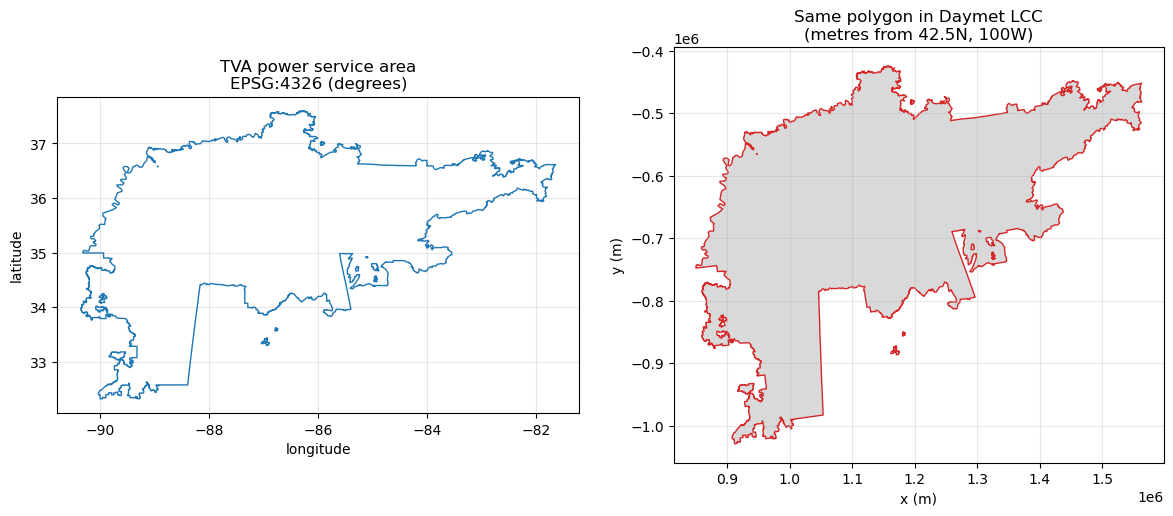

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

roi_wgs84.boundary.plot(ax=ax1, color="tab:blue", linewidth=1)
ax1.set_title("TVA power service area\nEPSG:4326 (degrees)")
ax1.set_xlabel("longitude"); ax1.set_ylabel("latitude")

roi_lcc.plot(ax=ax2, facecolor="0.85", edgecolor="tab:red", linewidth=1)
ax2.set_title("Same polygon in Daymet LCC\n(metres from 42.5N, 100W)")
ax2.set_xlabel("x (m)"); ax2.set_ylabel("y (m)")
for ax in (ax1, ax2):
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout()

## 4. Time range and variables of interest

A full year of daily 1 km data over the TVA footprint is roughly
`717 x 609 x 365 x 4 bytes` per variable (~640 MB), and a June-August season is about 160 MB.
Start with one season and one or two variables, confirm the workflow, then scale up.

Time is sliced with **date strings** rather than `datetime` objects, so the same code works whether
the granule's time axis decodes to `datetime64` or to `cftime` objects.

In [6]:
START = dt.datetime(2023, 4, 1)
END = dt.datetime(2023, 6, 30)
VARIABLES = ["tmax", "prcp"]      # any of tmax, tmin, prcp, srad, vp, swe, dayl
REGION = "na"                     # 'na' (North America), 'hi' (Hawaii), 'pr' (Puerto Rico)

YEARS = list(range(START.year, END.year + 1))
DT_FMT = "%Y-%m-%dT%H:%M:%SZ"
temporal_str = f"{START.strftime(DT_FMT)},{END.strftime(DT_FMT)}"

# string-based slice: works for datetime64 and cftime time axes alike
TIME_SLICE = slice(f"{START:%Y-%m-%d}", f"{END:%Y-%m-%d}")

print("time range :", temporal_str)
print("years      :", YEARS)
print("variables  :", VARIABLES)
print("region     :", REGION)

time range : 2023-04-01T00:00:00Z,2023-06-30T00:00:00Z
years      : [2023]
variables  : ['tmax', 'prcp']
region     : na


## 5. Discover OPeNDAP URLs from NASA's CMR

NASA's **Common Metadata Repository (CMR)** is the searchable index for everything in Earthdata.
`pydap.client.get_cmr_urls` queries CMR and returns the **OPeNDAP** URLs for the matching granules
directly — no manual JSON parsing of the granule response, and no hard-coded file paths.

You can search by `ccid` (collection concept ID), `doi`, or `short_name`. For Daymet Daily V4 R1:

* DOI: `10.3334/ORNLDAAC/2129`
* short name: `Daymet_Daily_V4R1_2129`
* concept ID: `C2532426483-ORNL_CLOUD`

URLs come back in the form
`https://opendap.earthdata.nasa.gov/collections/<ccid>/granules/<granule-name>`.

In [7]:
DOI = "10.3334/ORNLDAAC/2129"

# Resolve the collection concept ID from the DOI (handy if the collection is ever re-versioned)
doisearch = "https://cmr.earthdata.nasa.gov/search/collections.json?doi=" + DOI
CCID = requests.get(doisearch, timeout=60).json()["feed"]["entry"][0]["id"]
print("collection concept ID:", CCID)

collection concept ID: C2532426483-ORNL_CLOUD


In [8]:
cmr_urls = get_cmr_urls(ccid=CCID, time_range=[START, END], limit=1000)
print(f"{len(cmr_urls)} granule URLs returned by CMR for {START:%Y-%m-%d} to {END:%Y-%m-%d}")

# The collection bundles all variables and all three regions; keep only what we asked for.
def wanted(url, var, region, years):
    name = url.rsplit("/", 1)[-1]
    return any(f"daily_{region}_{var}_{y}.nc" in name for y in years)

urls = {
    var: sorted(u for u in cmr_urls if wanted(u, var, REGION, YEARS))
    for var in VARIABLES
}

for var, ulist in urls.items():
    print(f"\n{var}: {len(ulist)} granule(s)")
    for u in ulist:
        print("  ", u)

21 granule URLs returned by CMR for 2023-04-01 to 2023-06-30

tmax: 1 granule(s)
   https://opendap.earthdata.nasa.gov/collections/C2532426483-ORNL_CLOUD/granules/Daymet_Daily_V4R1.daymet_v4_daily_na_tmax_2023.nc

prcp: 1 granule(s)
   https://opendap.earthdata.nasa.gov/collections/C2532426483-ORNL_CLOUD/granules/Daymet_Daily_V4R1.daymet_v4_daily_na_prcp_2023.nc


> **Note on searching by bounding box.** `get_cmr_urls` also accepts `bounding_box=[W, S, E, N]`.
> Daymet granules are continental in extent, so a bounding-box filter mainly serves to exclude the
> Hawaii and Puerto Rico granules; here we filter on the region code in the filename instead,
> which is unambiguous.

## 6. Open a remote granule over DAP4 and inspect it

Two things matter here:

1. **Use the `dap4://` scheme.** Swapping `https://` for `dap4://` tells `pydap`/`xarray` to use 
   DAP4 syntax rather than the older DAP2, which is what the NASA Hyrax deployment expects for these files.
2. **Nothing is downloaded yet.** `xr.open_dataset(..., engine="pydap")` fetches only the DMR
   (metadata). Array values travel only when you slice and `.load()`/`.compute()` them, and Hyrax
   sends only the hyperslab you asked for.

In [9]:
def dap4(url: str) -> str:
    # Convert an https Earthdata OPeNDAP URL into a DAP4 URL
    return url.replace("https://", "dap4://", 1)


sample_url = urls[VARIABLES[0]][0]
print(dap4(sample_url), "\n")

ds = xr.open_dataset(
    dap4(sample_url),
    engine="pydap",
    session=my_session,
    decode_coords="all",   # attaches lat/lon and the lambert_conformal_conic grid mapping
)
ds

dap4://opendap.earthdata.nasa.gov/collections/C2532426483-ORNL_CLOUD/granules/Daymet_Daily_V4R1.daymet_v4_daily_na_tmax_2023.nc 



<xarray.Dataset> Size: 93GB
Dimensions:                  (time: 365, y: 8075, x: 7814, nv: 2)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 2023-01-01T12:00:00 .....
  * y                        (y) float32 32kB 4.984e+06 4.983e+06 ... -3.09e+06
  * x                        (x) float32 31kB -4.56e+06 -4.559e+06 ... 3.253e+06
    lon                      (y, x) float32 252MB ...
    lat                      (y, x) float32 252MB ...
    time_bnds                (time, nv) datetime64[ns] 6kB ...
    lambert_conformal_conic  int16 2B ...
Dimensions without coordinates: nv
Data variables:
    tmax                     (time, y, x) float32 92GB ...
    yearday                  (time) int16 730B ...
Attributes:
    start_year:        2023
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

In [10]:
# Daymet's native CRS straight from the granule metadata (compare with DAYMET_PROJ above)
print("CRS from file :", ds.rio.crs)
print("dims          :", dict(ds.sizes))
print("x range (m)   :", float(ds.x.min()), "->", float(ds.x.max()))
print("y range (m)   :", float(ds.y.min()), "->", float(ds.y.max()), "(descending: north to south)")
print("time          :", str(ds.time.values[0])[:10], "->", str(ds.time.values[-1])[:10])

CRS from file : PROJCS["undefined",GEOGCS["undefined",DATUM["undefined",SPHEROID["undefined",6378137,298.257223563]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",60],PARAMETER["latitude_of_origin",42.5],PARAMETER["central_meridian",-100],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
dims          : {'time': 365, 'y': 8075, 'x': 7814, 'nv': 2}
x range (m)   : -4560250.0 -> 3252750.0
y range (m)   : -3090000.0 -> 4984000.0 (descending: north to south)
time          : 2023-01-01 -> 2023-12-31


### How big is the request?

Estimate before you pull. `y` is stored **north to south (descending)**, so a `.sel()` slice on `y`
must be given as `slice(ymax, ymin)`.

In [11]:
def bbox_slices(dataset, bbox_lcc):
    # xarray .sel() slices for a Daymet granule, from an LCC bbox (xmin, ymin, xmax, ymax)
    xmin, ymin, xmax, ymax = bbox_lcc
    y_desc = bool(dataset.y[0] > dataset.y[-1])
    return {
        "x": slice(xmin, xmax),
        "y": slice(ymax, ymin) if y_desc else slice(ymin, ymax),
    }


sl = bbox_slices(ds, bbox_lcc)
probe = ds[VARIABLES[0]].sel(**sl).sel(time=TIME_SLICE)
n = int(np.prod(probe.shape))
print("subset shape      :", dict(zip(probe.dims, probe.shape)))
print("values            :", f"{n:,}")
print("approx. transfer  :", f"{n * 4 / 1e6:.0f} MB per variable")
print("full-granule size :", f"{int(np.prod(ds[VARIABLES[0]].shape)) * 4 / 1e9:.1f} GB")
print("reduction         :", f"{int(np.prod(ds[VARIABLES[0]].shape)) / n:,.0f}x smaller")

subset shape      : {'time': 91, 'y': 609, 'x': 717}
values            : 39,735,423
approx. transfer  : 159 MB per variable
full-granule size : 92.1 GB
reduction         : 580x smaller


In [12]:
sl

{'x': slice(np.float64(848090.8969096304), np.float64(1565383.573167402), None),
 'y': slice(np.float64(-422553.4359278971), np.float64(-1031136.1577225582), None)}

## 7. Subset in space and time, then stream it down

The loop below opens each granule lazily, slices it to the TVA bounding box and the date range,
concatenates multi-year granules along `time`, and calls `.load()` once — that single call is where
the network transfer happens. Results are written to netCDF so later steps (and later sessions)
don't re-request anything.

If a request times out, shrink the date range or the box rather than retrying blindly; Hyrax is
happier with several moderate requests than with one enormous one.

In [13]:
subsets = {}

for var, ulist in urls.items():
    t0 = time.time()
    pieces = []
    for u in ulist:
        print(f"opening {u.rsplit('/', 1)[-1]} ...", flush=True)
        with xr.open_dataset(dap4(u), engine="pydap", session=my_session,
                             decode_coords="all") as gds:
            sl = bbox_slices(gds, bbox_lcc)
            piece = gds[[var]].sel(**sl).sel(time=TIME_SLICE)
            pieces.append(piece.load())          # <- data transferred here
    da = xr.concat(pieces, dim="time").sortby("time") if len(pieces) > 1 else pieces[0]
    da = da.rio.write_crs(DAYMET_PROJ)
    subsets[var] = da
    print(f"  {var}: {dict(da.sizes)} in {time.time() - t0:.1f} s\n")

subset = xr.merge(subsets.values())
subset.attrs["title"] = "Daymet V4 R1 daily subset, TVA power service area"
subset.attrs["source"] = "NASA Earthdata Cloud OPeNDAP (Hyrax), collection " + CCID
subset.attrs["history"] = f"Subset via DAP4 on {dt.date.today():%Y-%m-%d}"
subset

opening Daymet_Daily_V4R1.daymet_v4_daily_na_tmax_2023.nc ...
  tmax: {'time': 91, 'y': 609, 'x': 717} in 43.6 s

opening Daymet_Daily_V4R1.daymet_v4_daily_na_prcp_2023.nc ...
  prcp: {'time': 91, 'y': 609, 'x': 717} in 41.3 s



<xarray.Dataset> Size: 321MB
Dimensions:                  (time: 91, y: 609, x: 717)
Coordinates:
  * time                     (time) datetime64[ns] 728B 2023-04-01T12:00:00 ....
  * y                        (y) float32 2kB -4.23e+05 -4.24e+05 ... -1.031e+06
  * x                        (x) float32 3kB 8.488e+05 8.498e+05 ... 1.565e+06
    lon                      (y, x) float32 2MB -89.88 -89.87 ... -83.01 -83.0
    lat                      (y, x) float32 2MB 38.03 38.02 ... 31.33 31.33
    lambert_conformal_conic  int64 8B 0
Data variables:
    tmax                     (time, y, x) float32 159MB 15.96 15.95 ... 34.67
    prcp                     (time, y, x) float32 159MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    start_year:        2023
    source:            NASA Earthdata Cloud OPeNDAP (Hyrax), collection C2532...
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...
    title:             Daymet V4 R1 daily subset, TVA power service area
    history:           Subset via DAP4 on 2026-09-23

In [14]:
sl

{'x': slice(np.float64(848090.8969096304), np.float64(1565383.573167402), None),
 'y': slice(np.float64(-422553.4359278971), np.float64(-1031136.1577225582), None)}

In [15]:
out_nc = WORKDIR / "data" / (
    f"daymet_v4_tva_{'_'.join(VARIABLES)}_{START:%Y%m%d}_{END:%Y%m%d}.nc"
)
encoding = {v: {"zlib": True, "complevel": 4} for v in VARIABLES}
subset.to_netcdf(out_nc, encoding=encoding)
print(f"wrote {out_nc}  ({out_nc.stat().st_size / 1e6:.1f} MB on disk)")

wrote daymet_tva/data/daymet_v4_tva_tmax_prcp_20230401_20230630.nc  (94.6 MB on disk)


## 8. Clip to the TVA polygon and export

The bounding-box subset still contains cells outside the service area. `rioxarray.clip` masks to the
polygon itself. Since the data and the polygon are both in Daymet LCC, no reprojection is needed.

In [16]:
from shapely.geometry import mapping

clipped = subset.rio.clip(
    roi_lcc.geometry.apply(mapping), roi_lcc.crs, drop=False, all_touched=True
)

out_clip = out_nc.with_name(out_nc.stem + "_tvaclip.nc")
clipped.to_netcdf(out_clip, encoding=encoding)
print("wrote", out_clip)

frac = float(clipped[VARIABLES[0]].isel(time=0).notnull().mean())
print(f"{frac:.0%} of the bounding-box cells fall inside the TVA polygon")

wrote daymet_tva/data/daymet_v4_tva_tmax_prcp_20230401_20230630_tvaclip.nc
43% of the bounding-box cells fall inside the TVA polygon


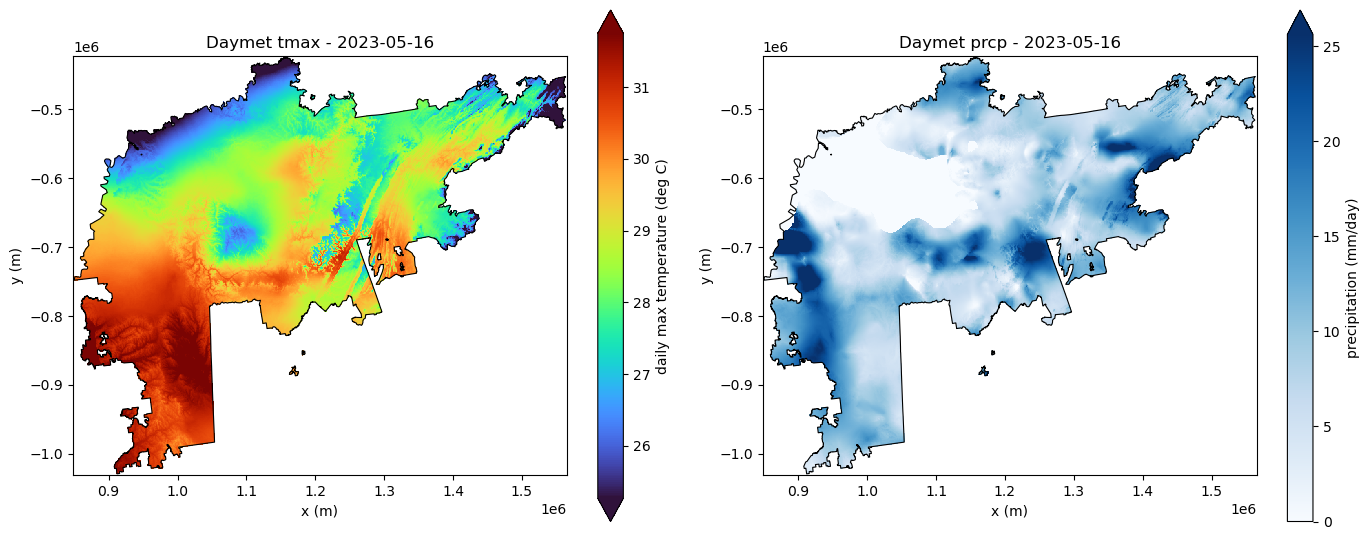

In [17]:
day = clipped.time.values[len(clipped.time) // 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, var, cmap, label in zip(
    axes, VARIABLES, ["turbo", "Blues"],
    ["daily max temperature (deg C)", "precipitation (mm/day)"],
):
    clipped[var].sel(time=day).plot(
        ax=ax, cmap=cmap, robust=True, cbar_kwargs={"label": label}
    )
    roi_lcc.boundary.plot(ax=ax, color="black", linewidth=0.8)
    ax.set_title(f"Daymet {var} - {str(day)[:10]}")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(WORKDIR / "tva_daily_maps.png", dpi=150, bbox_inches="tight")

wrote daymet_v4_tva_tmax_mean_20230401_20230630.tif
wrote daymet_v4_tva_tmax_days_above_32C_20230401_20230630.tif
wrote daymet_v4_tva_prcp_total_20230401_20230630.tif


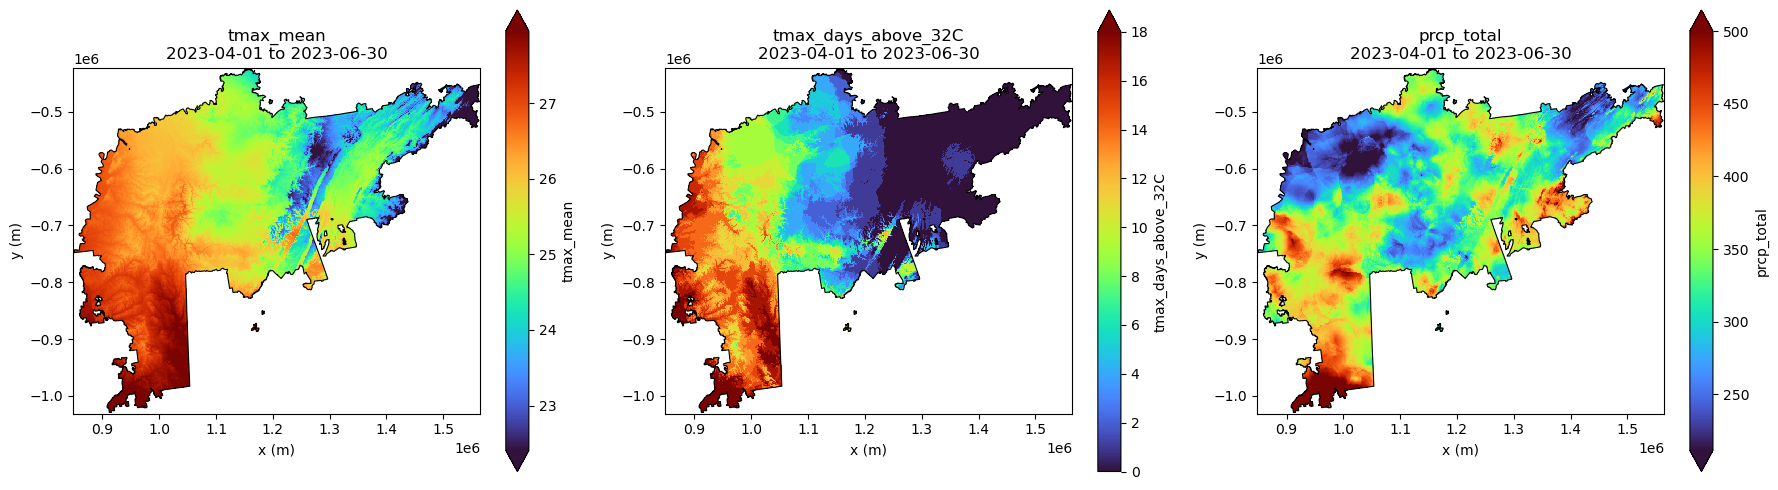

In [18]:
# Season summaries over the clipped region, exported as Cloud-friendly GeoTIFFs
summaries = {
    f"{VARIABLES[0]}_mean": clipped[VARIABLES[0]].mean("time", keep_attrs=True),
    f"{VARIABLES[0]}_days_above_32C": (clipped[VARIABLES[0]] > 32).sum("time").where(
        clipped[VARIABLES[0]].isel(time=0).notnull()
    ),
}
if "prcp" in VARIABLES:
    summaries["prcp_total"] = clipped["prcp"].sum("time", keep_attrs=True).where(
        clipped["prcp"].isel(time=0).notnull()
    )

for name, da in summaries.items():
    da = da.rio.write_crs(DAYMET_PROJ)
    tif = WORKDIR / "data" / f"daymet_v4_tva_{name}_{START:%Y%m%d}_{END:%Y%m%d}.tif"
    da.rio.to_raster(tif)
    print("wrote", tif.name)

fig, axes = plt.subplots(1, len(summaries), figsize=(6 * len(summaries), 5))
for ax, (name, da) in zip(np.atleast_1d(axes), summaries.items()):
    da.plot(ax=ax, robust=True, cmap="turbo", cbar_kwargs={"label": name})
    roi_lcc.boundary.plot(ax=ax, color="black", linewidth=0.8)
    ax.set_title(f"{name}\n{START:%Y-%m-%d} to {END:%Y-%m-%d}")
    ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
plt.tight_layout()
fig.savefig(WORKDIR / "tva_season_summaries.png", dpi=150, bbox_inches="tight")

In [19]:
### for fun: daily precipitation GIF from all 91 days, with one fixed color scale so the frames are comparable

prcp = clipped["prcp"]  

# Keep one scale for all 91 frames; avoids color changes from day to day.
vmin = 0
vmax = float(prcp.quantile(0.99))
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(7, 6))
colorbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap="Blues"),
    ax=ax,
    label="precipitation (mm/day)",
)

def draw_frame(i):
    ax.clear()

    day = prcp.time.values[i]
    prcp.isel(time=i).plot(
        ax=ax,
        cmap="Blues",
        norm=norm,
        add_colorbar=False,
    )

    roi_lcc.boundary.plot(ax=ax, color="black", linewidth=0.8)
    ax.set_title(f"Daymet precipitation — {str(day)[:10]}")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")

animation = FuncAnimation(
    fig,
    draw_frame,
    frames=prcp.sizes["time"],
    interval=125,  # milliseconds per frame
)

gif_path = WORKDIR / "tva_daily_precipitation.gif"
animation.save(
    gif_path,
    writer=PillowWriter(fps=8),
    dpi=120,
)

plt.close(fig)
print(f"Saved: {gif_path}")

Saved: daymet_tva/tva_daily_precipitation.gif


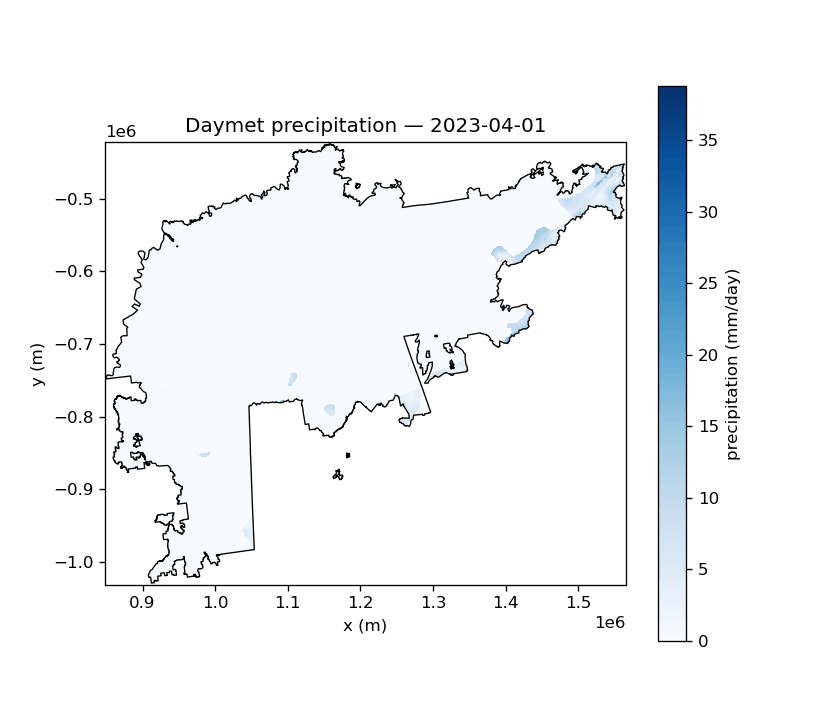

In [20]:
Image(filename=str(gif_path))

## 9. Regional analyses

With the subset in memory, ordinary `xarray` reductions give the products a regional center
typically wants: area-average daily series, extremes, and single-pixel extractions for a city or
gauge location.

Area-mean tmax  : 25.59 deg C
Hottest day     : 2023-06-30 (33.47 deg C area mean)
Area-mean total precipitation: 337 mm


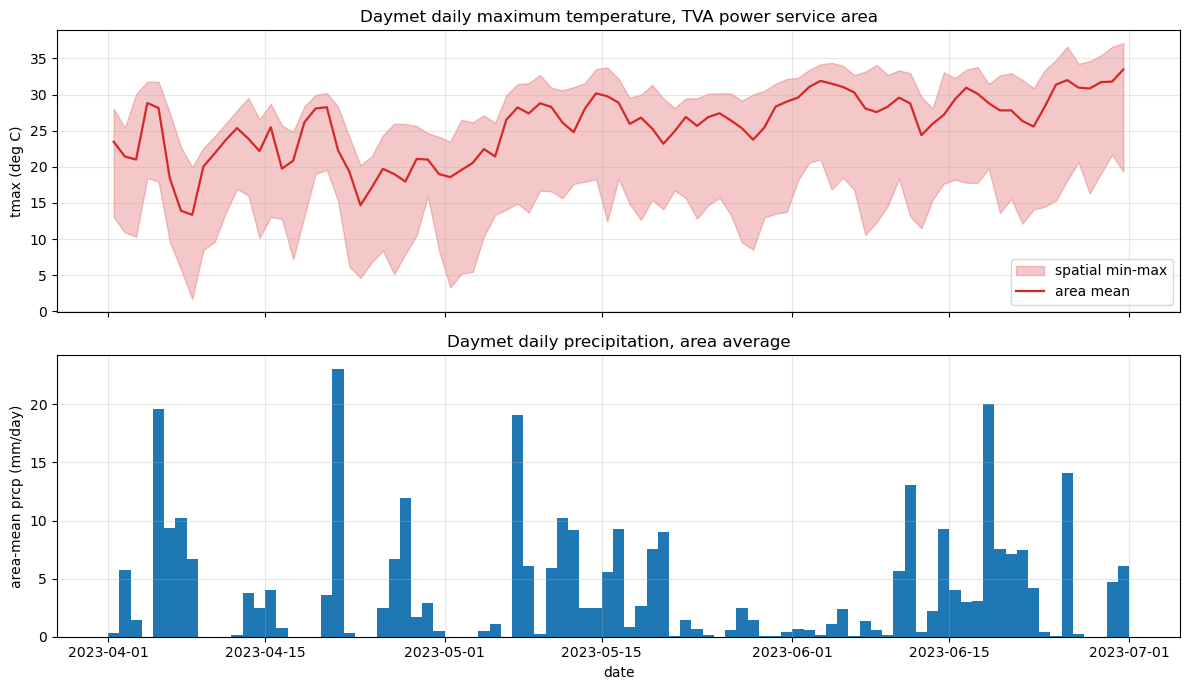

In [21]:
area_mean = clipped[VARIABLES[0]].mean(dim=("x", "y"))
area_max = clipped[VARIABLES[0]].max(dim=("x", "y"))
area_min = clipped[VARIABLES[0]].min(dim=("x", "y"))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].fill_between(clipped.time, area_min, area_max, alpha=0.25,
                     color="tab:red", label="spatial min-max")
axes[0].plot(clipped.time, area_mean, color="tab:red", lw=1.6, label="area mean")
axes[0].set_ylabel("tmax (deg C)")
axes[0].set_title("Daymet daily maximum temperature, TVA power service area")
axes[0].legend(); axes[0].grid(alpha=0.3)

if "prcp" in VARIABLES:
    axes[1].bar(clipped.time, clipped["prcp"].mean(dim=("x", "y")),
                width=1.0, color="tab:blue")
    axes[1].set_ylabel("area-mean prcp (mm/day)")
    axes[1].set_title("Daymet daily precipitation, area average")
    axes[1].grid(alpha=0.3)
axes[1].set_xlabel("date")
plt.tight_layout()
fig.savefig(WORKDIR / "tva_timeseries.png", dpi=150, bbox_inches="tight")

print(f"Area-mean tmax  : {float(area_mean.mean()):.2f} deg C")
print(f"Hottest day     : {str(area_mean.idxmax().values)[:10]} "
      f"({float(area_mean.max()):.2f} deg C area mean)")
if "prcp" in VARIABLES:
    tot = float(clipped['prcp'].mean(dim=('x', 'y')).sum())
    print(f"Area-mean total precipitation: {tot:.0f} mm")

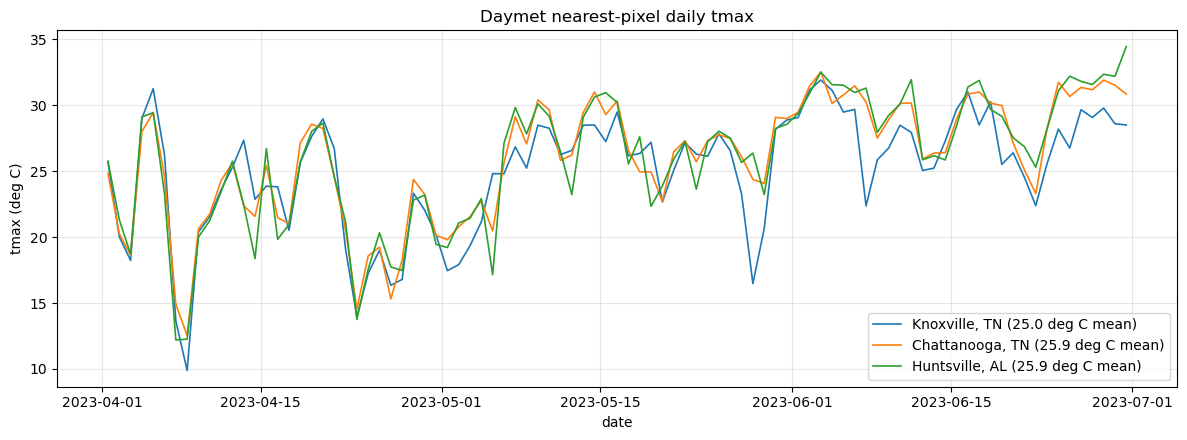

In [22]:
# Single-pixel ("Daymet single pixel extraction" style) time series for selected sites
sites = {
    "Knoxville, TN": (-83.9207, 35.9606),
    "Chattanooga, TN": (-85.3097, 35.0456),
    "Huntsville, AL": (-86.5861, 34.7304),
}
site_pts = gpd.GeoDataFrame(
    {"site": list(sites)},
    geometry=gpd.points_from_xy(*zip(*sites.values())),
    crs="EPSG:4326",
).to_crs(DAYMET_PROJ)

fig, ax = plt.subplots(figsize=(12, 4.5))
for name, pt in zip(site_pts.site, site_pts.geometry):
    ts = clipped[VARIABLES[0]].sel(x=pt.x, y=pt.y, method="nearest")
    ax.plot(ts.time, ts, lw=1.2, label=f"{name} ({float(ts.mean()):.1f} deg C mean)")
ax.set_ylabel("tmax (deg C)"); ax.set_xlabel("date")
ax.set_title("Daymet nearest-pixel daily tmax")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(WORKDIR / "tva_site_timeseries.png", dpi=150, bbox_inches="tight")

## 10. Optional: bulk streaming with `pydap.client.to_netcdf`

For many granules — say `tmax` for 1980-2024 — the `xarray` route above is convenient but serial.
`pydap.client.to_netcdf` streams a list of DAP4 URLs straight to local netCDF files in parallel,
requesting only the variables and index ranges you name. It is the fastest path for building a
multi-decadal regional archive.

Two differences from the `xarray` workflow:

* variables are given as **DAP4 paths** (`"/tmax"`, `"/x"`, ... — the leading `/` is the root group);
* slices are **integer index ranges** `(first, last)`, not coordinate values — so we convert the
  LCC bounding box into `x`/`y` indices first.

In [23]:
def index_slices(dataset, bbox_lcc):
    # Convert an LCC bbox into DAP4 integer dim_slices for /x and /y
    xmin, ymin, xmax, ymax = bbox_lcc
    xv = np.asarray(dataset.x); yv = np.asarray(dataset.y)
    xi = np.where((xv >= xmin) & (xv <= xmax))[0]
    yi = np.where((yv >= ymin) & (yv <= ymax))[0]
    return {"/x": (int(xi.min()), int(xi.max())), "/y": (int(yi.min()), int(yi.max()))}


dim_slices = index_slices(ds, bbox_lcc)
print("dim_slices:", dim_slices)

dim_slices: {'/x': (5409, 6125), '/y': (5407, 6015)}


### Data files are large, so downloading in chunks.

In [24]:
BULK = True # Turn off to False to avoid downloading.
if BULK:
    bulk_years = list(range(2015, 2025))

    bulk_cmr_urls = get_cmr_urls(
        ccid=CCID,
        time_range=[
            dt.datetime(bulk_years[0], 1, 1),
            dt.datetime(bulk_years[-1], 12, 31),
        ],
        limit=1000,
    )

    # Leave these as https:// URLs for dap_to_netcdf.
    bulk_urls = [
        u for u in bulk_cmr_urls
        if wanted(u, "tmax", REGION, bulk_years)
    ]

    print(f"streaming {len(bulk_urls)} granules")
    bulk_dir = Path(WORKDIR) / "data" / "bulk"
    bulk_dir.mkdir(parents=True, exist_ok=True)
    print("Writing to:", bulk_dir.resolve())
    probe = bulk_dir / ".permission_check"
    probe.write_text("ok")
    probe.unlink()

    tile_root = Path(WORKDIR) / "data" / "tiles"
    final_dir = Path(WORKDIR) / "data" / "bulk"
    tile_root.mkdir(parents=True, exist_ok=True)
    final_dir.mkdir(parents=True, exist_ok=True)
    
    # Recover the existing spatial bounds.
    y0, y1 = dim_slices["/y"]
    x0, x1 = dim_slices["/x"]
    
    strip_height = 48  # lower this to 48 if a strip still times out
    
    for url in bulk_urls:
        year_name = url.rsplit("/", 1)[-1]
        print(f"\nDownloading {year_name}")
    
        tile_files = []
    
        for ys in range(y0, y1, strip_height):
            ye = min(ys + strip_height, y1)
            tile_dir = tile_root / f"{year_name}_y{ys}_{ye}"
            tile_dir.mkdir(parents=True, exist_ok=True)
    
            print(f"  y indices {ys}:{ye}")
            dap_to_netcdf(
                [url],
                session=my_session,
                output_path=str(tile_dir),
                keep_variables=["/time", "/y", "/x", "/lat", "/lon", "/tmax"],
                dim_slices={
                    "/y": (ys, ye),
                    "/x": (x0, x1),
                },
            )
            tile_files.extend(tile_dir.glob("*.nc4"))
        # Reassemble that year's y-strips into one local NetCDF file.
        with xr.open_mfdataset(
            [str(p) for p in tile_files],
            combine="by_coords",
            decode_coords="all",
        ) as ds:
            ds.load().to_netcdf(final_dir / f"{year_name}.nc4")
else:
    print("BULK is False - set it to True to stream the multi-year archive.")

streaming 10 granules
Writing to: /Users/ud4/repos/GitHub/sharma-bharat/DAAC/Task1/daymet_tva/data/bulk

  y indices 5407:5455
  y indices 5455:5503
  y indices 5503:5551
  y indices 5551:5599
  y indices 5599:5647
  y indices 5647:5695
  y indices 5695:5743
  y indices 5743:5791
  y indices 5791:5839
  y indices 5839:5887
  y indices 5887:5935
  y indices 5935:5983
  y indices 5983:6015

  y indices 5407:5455
  y indices 5455:5503
  y indices 5503:5551
  y indices 5551:5599
  y indices 5599:5647
  y indices 5647:5695
  y indices 5695:5743
  y indices 5743:5791
  y indices 5791:5839
  y indices 5839:5887
  y indices 5887:5935
  y indices 5935:5983
  y indices 5983:6015

  y indices 5407:5455
  y indices 5455:5503
  y indices 5503:5551
  y indices 5551:5599
  y indices 5599:5647
  y indices 5647:5695
  y indices 5695:5743
  y indices 5743:5791
  y indices 5791:5839
  y indices 5839:5887
  y indices 5887:5935
  y indices 5935:5983
  y indices 5983:6015

  y indices 5407:5455
  y indices 

In [25]:
# Open the finished yearly files
print (f"The final datasets are stored here: {final_dir}.")
ds_bulk = xr.open_mfdataset(
    str(final_dir / "*.nc4"),
    combine="by_coords",
    decode_coords="all",
)
ds_bulk

The final datasets are stored here: daymet_tva/data/bulk.


<xarray.Dataset> Size: 19GB
Dimensions:  (time: 3650, y: 608, x: 716)
Coordinates:
  * time     (time) datetime64[ns] 29kB 2015-01-01T12:00:00 ... 2024-12-30T12...
  * y        (y) float32 2kB -4.23e+05 -4.24e+05 ... -1.029e+06 -1.03e+06
  * x        (x) float32 3kB 8.488e+05 8.498e+05 ... 1.563e+06 1.564e+06
    lon      (time, y, x) float32 6GB dask.array<chunksize=(322, 322, 322), meta=np.ndarray>
    lat      (time, y, x) float32 6GB dask.array<chunksize=(322, 322, 322), meta=np.ndarray>
Data variables:
    tmax     (time, y, x) float32 6GB dask.array<chunksize=(365, 608, 716), meta=np.ndarray>
Attributes:
    start_year:        2015
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

**SAVE STORAGE: Delete the dir `tiles`, since data is concated from tiles and is stored in the `bulk` dir**

### Smoke Test. If the code above does not work, test if your connections are setup correct

In [26]:
BULK = True

if BULK:
    bulk_years = list(range(2015, 2025))

    bulk_cmr_urls = get_cmr_urls(
        ccid=CCID,
        time_range=[
            dt.datetime(bulk_years[0], 1, 1),
            dt.datetime(bulk_years[-1], 12, 31),
        ],
        limit=1000,
    )

    # Leave these as https:// URLs for dap_to_netcdf.
    bulk_urls = [
        u for u in bulk_cmr_urls
        if wanted(u, "tmax", REGION, bulk_years)
    ]

    smoke_dir = Path(WORKDIR) / "data" / "smoke_test"
    smoke_dir.mkdir(parents=True, exist_ok=True)

    tiny_slices = {
    "/time": (0, 1),
    "/y": (0, 9),
    "/x": (0, 9),
    }

    dap_to_netcdf(
    bulk_urls[:1],            # one HTTPS URL only
    session=my_session,
    output_path=str(smoke_dir),
    keep_variables=["/time", "/y", "/x", "/tmax"],
    dim_slices=tiny_slices,
    )

    print("done. Open the result with:")
    print("  xr.open_mfdataset(str(WORKDIR / 'data' / 'smoke_test' / '*.nc'), decode_coords='all')")
else:
    print("BULK is False - set it to True to stream the multi-year archive.")

done. Open the result with:
  xr.open_mfdataset(str(WORKDIR / 'data' / 'smoke_test' / '*.nc'), decode_coords='all')


## 11. Resources

* [Daymet Daily V4 R1 in the Earthdata catalog](https://www.earthdata.nasa.gov/data/catalog/ornl-cloud-daymet-daily-v4r1-2129-4.1)
* [NASA Earthdata OPeNDAP (Hyrax)](https://opendap.earthdata.nasa.gov/)
* [OPeNDAP tutorial: Accessing DAYMET data from NASA's archives](https://www.opendap.org/accessing-daymet-data-from-nasas-archives/)
* [PyDAP documentation — authentication](https://pydap.github.io/pydap/en/notebooks/Authentication.html)
* [earthaccess documentation](https://earthaccess.readthedocs.io/)
* [Daymet Daily V4 R1 User Guide](https://daac.ornl.gov/DAYMET/guides/Daymet_Daily_V4R1.html)
* [ORNL DAAC daymet-python-opendap-xarray (legacy THREDDS notebooks)](https://github.com/ornldaac/daymet-python-opendap-xarray)
* [earthdata_hyraxOPeNDAP_access (earlier Hyrax drafts)](https://github.com/michele-personal/earthdata_hyraxOPeNDAP_access)
* [Daymet Single Pixel Extraction Tool](https://daymet.ornl.gov/single-pixel/) and [AppEEARS](https://appeears.earthdatacloud.nasa.gov/) for point/area extractions without code
